## Goal
Predict `delivery_days` (time between order purchase and delivery to customer)
using features known at or before order placement, from the Olist e-commerce dataset.

## Approach
- Engineer features from order, product, seller, customer, payment, and geolocation data
- Explicitly exclude any timestamp or status field only known *after* delivery,
  to avoid data leakage
- Compare linear models (with regularization) against XGBoost to test whether
  the relationship between features and delivery time is linear or not

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
customers = pd.read_csv("C:\\Users\\ravic\\Downloads\\olist_customers_dataset.csv")
orders = pd.read_csv("C:\\Users\\ravic\\Downloads\\olist_orders_dataset.csv")
order_items = pd.read_csv("C:\\Users\\ravic\\Downloads\\olist_order_items_dataset.csv")
order_payments = pd.read_csv("C:\\Users\\ravic\\Downloads\\olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("C:\\Users\\ravic\\Downloads\\olist_order_reviews_dataset.csv")
products = pd.read_csv("C:\\Users\\ravic\\Downloads\\olist_products_dataset.csv")
sellers = pd.read_csv("C:\\Users\\ravic\\Downloads\\olist_sellers_dataset.csv")
geolocation = pd.read_csv("C:\\Users\\ravic\\Downloads\\olist_geolocation_dataset.csv")
category_translation = pd.read_csv("C:\\Users\\ravic\\Downloads\\product_category_name_translation.csv")

In [4]:
# ============================================================
# STEP 1: CANDIDATE FEATURE POOL
# ============================================================

candidate_features = {

    # --------------------------------------------------------
    # ORDERS TABLE
    # --------------------------------------------------------
    "orders": [
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_estimated_delivery_date"
    ],

    # --------------------------------------------------------
    # ORDER ITEMS TABLE
    # --------------------------------------------------------
    "order_items": [
        "order_item_id",
        "product_id",
        "seller_id",
        "shipping_limit_date",
        "price",
        "freight_value"
    ],

    # --------------------------------------------------------
    # PRODUCTS TABLE
    # --------------------------------------------------------
    "products": [
        "product_category_name",
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ],

    # --------------------------------------------------------
    # SELLERS TABLE
    # --------------------------------------------------------
    "sellers": [
        "seller_zip_code_prefix",
        "seller_city",
        "seller_state"
    ],

    # --------------------------------------------------------
    # CUSTOMERS TABLE
    # --------------------------------------------------------
    "customers": [
        "customer_zip_code_prefix",
        "customer_city",
        "customer_state"
    ],

    # --------------------------------------------------------
    # PAYMENTS TABLE
    # --------------------------------------------------------
    "order_payments": [
        "payment_type",
        "payment_installments",
        "payment_value"
    ],

    # --------------------------------------------------------
    # REVIEWS TABLE
    # --------------------------------------------------------
    "order_reviews": [
        "review_score",
        "review_creation_date",
        "review_answer_timestamp"
    ],

    # --------------------------------------------------------
    # GEOLOCATION TABLE
    # --------------------------------------------------------
    "geolocation": [
        "geolocation_zip_code_prefix",
        "geolocation_lat",
        "geolocation_lng",
        "geolocation_city",
        "geolocation_state"
    ]
}

# **Feature Engineering :**

## Feature Engineering
Features are built at four levels and merged onto the order:

- **Order-level**: number of items, number of unique sellers/products per order
- **Product-level**: average/total price, weight, and volume of items in the order
- **Geolocation**: seller-customer distance (haversine, km) and a same-state flag,
  since Brazilian logistics networks are largely organized around state boundaries
- **Payment**: payment type, number of installments
- **Temporal**: purchase month, quarter, year, day of week

Each merge is validated with a `merge_check`/shape check to confirm no unexpected
row duplication or loss before moving forward.

In [7]:
#First, we create our target delivery_days from the orders table.
# Make a copy of the orders table
model_df = orders.copy()

# Convert relevant timestamp columns to datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    model_df[col] = pd.to_datetime(model_df[col], errors='coerce')

# Create target variable: delivery time in days
model_df['delivery_days'] = (
    model_df['order_delivered_customer_date']
    - model_df['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

# Check the result
model_df[['order_id',
          'order_purchase_timestamp',
          'order_delivered_customer_date',
          'delivery_days']].head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2.873877


In [8]:
print("Number of orders:", len(model_df))

print("\nDelivery days summary:")
print(model_df['delivery_days'].describe())

print("\nMissing delivery days:")
print(model_df['delivery_days'].isna().sum())

print("\nNegative delivery days:")
print((model_df['delivery_days'] < 0).sum())

Number of orders: 99441

Delivery days summary:
count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64

Missing delivery days:
2965

Negative delivery days:
0


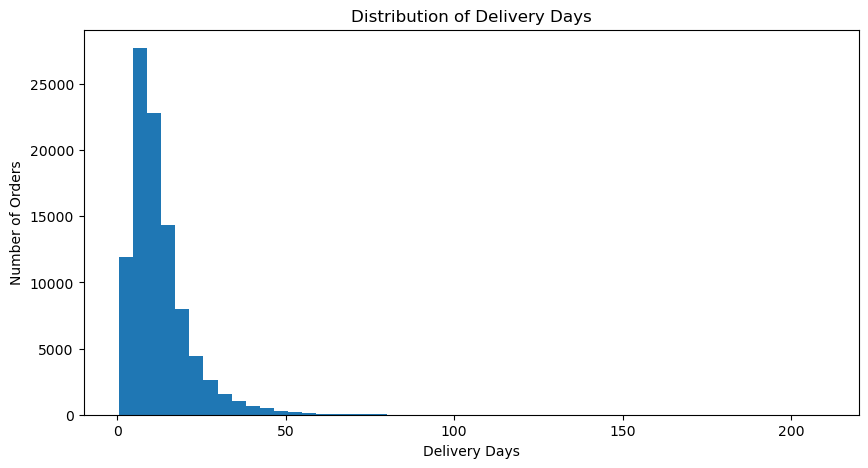

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(model_df['delivery_days'].dropna(), bins=50)
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.title('Distribution of Delivery Days')
plt.show()

In [10]:
#creating order level temporal features

model_df['purchase_year'] = (
    model_df['order_purchase_timestamp'].dt.year
)

model_df['purchase_month'] = (
    model_df['order_purchase_timestamp'].dt.month
)

model_df['purchase_quarter'] = (
    model_df['order_purchase_timestamp'].dt.quarter
)

model_df['purchase_day'] = (
    model_df['order_purchase_timestamp'].dt.day
)

model_df['purchase_weekday'] = (
    model_df['order_purchase_timestamp'].dt.dayofweek
)

model_df['purchase_hour'] = (
    model_df['order_purchase_timestamp'].dt.hour
)

model_df['purchase_is_weekend'] = (
    model_df['purchase_weekday'] >= 5
).astype(int)

In [11]:
model_df[
    [
        'order_id',
        'order_purchase_timestamp',
        'purchase_year',
        'purchase_month',
        'purchase_quarter',
        'purchase_day',
        'purchase_weekday',
        'purchase_hour',
        'purchase_is_weekend'
    ]
].head()

,order_id,order_purchase_timestamp,purchase_year,purchase_month,purchase_quarter,purchase_day,purchase_weekday,purchase_hour,purchase_is_weekend
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017,10,4,2,0,10,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018,7,3,24,1,20,0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018,8,3,8,2,8,0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017,11,4,18,5,19,1
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018,2,1,13,1,21,0


In [12]:
print("Purchase year:")
print(model_df['purchase_year'].value_counts().sort_index())

print("\nPurchase month:")
print(model_df['purchase_month'].value_counts().sort_index())

print("\nPurchase weekday:")
print(model_df['purchase_weekday'].value_counts().sort_index())

print("\nPurchase hour:")
print(model_df['purchase_hour'].value_counts().sort_index())

print("\nWeekend vs weekday:")
print(model_df['purchase_is_weekend'].value_counts())

Purchase year:
purchase_year
2016      329
2017    45101
2018    54011
Name: count, dtype: int64

Purchase month:
purchase_month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: count, dtype: int64

Purchase weekday:
purchase_weekday
0    16196
1    15963
2    15552
3    14761
4    14122
5    10887
6    11960
Name: count, dtype: int64

Purchase hour:
purchase_hour
0     2394
1     1170
2      510
3      272
4      206
5      188
6      502
7     1231
8     2967
9     4785
10    6177
11    6578
12    5995
13    6518
14    6569
15    6454
16    6675
17    6150
18    5769
19    5982
20    6193
21    6217
22    5816
23    4123
Name: count, dtype: int64

Weekend vs weekday:
purchase_is_weekend
0    76594
1    22847
Name: count, dtype: int64


In [13]:
#engineer order_items feature.
# Convert shipping limit to datetime
order_items['shipping_limit_date'] = pd.to_datetime(
    order_items['shipping_limit_date'],
    errors='coerce'
)

# Basic order-level item features
order_item_features = (
    order_items
    .groupby('order_id')
    .agg(
        num_items=('order_item_id', 'count'),
        num_products=('product_id', 'nunique'),
        num_sellers=('seller_id', 'nunique')
    )
    .reset_index()
)

order_item_features.head()

,order_id,num_items,num_products,num_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1
1,00018f77f2f0320c557190d7a144bdd3,1,1,1
2,000229ec398224ef6ca0657da4fc703e,1,1,1
3,00024acbcdf0a6daa1e931b038114c75,1,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1


In [14]:
price_freight_features = (
    order_items
    .groupby('order_id')
    .agg(
        total_price=('price', 'sum'),
        avg_price=('price', 'mean'),
        max_price=('price', 'max'),
        total_freight=('freight_value', 'sum'),
        avg_freight=('freight_value', 'mean')
    )
    .reset_index()
)

price_freight_features.head()

,order_id,total_price,avg_price,max_price,total_freight,avg_freight
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,58.90,58.90,13.29,13.29
1,00018f77f2f0320c557190d7a144bdd3,239.90,239.90,239.90,19.93,19.93
2,000229ec398224ef6ca0657da4fc703e,199.00,199.00,199.00,17.87,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.99,12.99,12.79,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,199.90,199.90,18.14,18.14


In [15]:
shipping_features = (
    order_items
    .groupby('order_id')
    .agg(
        shipping_limit_date=('shipping_limit_date', 'max')
    )
    .reset_index()
)

In [16]:
shipping_features = shipping_features.merge(
    model_df[
        ['order_id', 'order_purchase_timestamp']
    ],
    on='order_id',
    how='left',
    validate='one_to_one'
)

In [17]:
shipping_features['shipping_limit_delay_days'] = (
    shipping_features['shipping_limit_date']
    - shipping_features['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

In [18]:
shipping_features[
    [
        'order_id',
        'order_purchase_timestamp',
        'shipping_limit_date',
        'shipping_limit_delay_days'
    ]
].head()

,order_id,order_purchase_timestamp,shipping_limit_date,shipping_limit_delay_days
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02,2017-09-19 09:45:35,6.032326
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,2017-05-03 11:05:13,7.008414
2,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,2018-01-18 14:48:30,4.010405
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,2018-08-15 10:10:18,7.006748
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,2017-02-13 13:57:51,9.000000


In [19]:
order_item_features = (
    order_item_features
    .merge(
        price_freight_features,
        on='order_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        shipping_features[
            [
                'order_id',
                'shipping_limit_date',
                'shipping_limit_delay_days'
            ]
        ],
        on='order_id',
        how='left',
        validate='one_to_one'
    )
)

In [20]:
print("Rows:", len(order_item_features))
print("Columns:", len(order_item_features.columns))

order_item_features.head()

Rows: 98666
Columns: 11


,order_id,num_items,num_products,num_sellers,total_price,avg_price,max_price,total_freight,avg_freight,shipping_limit_date,shipping_limit_delay_days
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,58.90,58.90,13.29,13.29,2017-09-19 09:45:35,6.032326
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,239.90,239.90,19.93,19.93,2017-05-03 11:05:13,7.008414
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,199.00,199.00,17.87,17.87,2018-01-18 14:48:30,4.010405
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.99,12.99,12.79,12.79,2018-08-15 10:10:18,7.006748
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,199.90,199.90,18.14,18.14,2017-02-13 13:57:51,9.000000


In [21]:
print(
    "Rows:",
    len(order_item_features)
)

print(
    "Unique order IDs:",
    order_item_features['order_id'].nunique()
)

print(
    "Duplicate order IDs:",
    order_item_features['order_id'].duplicated().sum()
)

Rows: 98666
Unique order IDs: 98666
Duplicate order IDs: 0


In [22]:
order_item_features.describe()

,num_items,num_products,num_sellers,total_price,avg_price,max_price,total_freight,avg_freight,shipping_limit_date,shipping_limit_delay_days
count,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000,98666,98666.000000
mean,1.141731,1.038098,1.013622,137.754076,125.919255,126.631705,22.823562,20.190469,2018-01-07 12:54:18.369002752,6.617315
min,1.000000,1.000000,1.000000,0.850000,0.850000,0.850000,0.000000,0.000000,2016-09-19 00:15:34,2.004236
25%,1.000000,1.000000,1.000000,45.900000,41.990000,42.200000,13.850000,13.370000,2017-09-20 02:55:30,5.006542
50%,1.000000,1.000000,1.000000,86.900000,79.000000,79.900000,17.170000,16.360000,2018-01-26 13:52:23.500000,6.011748
75%,1.000000,1.000000,1.000000,149.900000,139.900000,139.900000,24.040000,21.180000,2018-05-10 15:14:05.249999872,7.156432
max,21.000000,8.000000,5.000000,13440.000000,6735.000000,6735.000000,1794.960000,409.680000,2020-04-09 22:35:08,1056.041667
std,0.538452,0.226456,0.122297,210.645145,190.985636,191.688201,21.650909,15.797846,NaN,6.659273


In [23]:
print("Missing values:")
print(order_item_features.isna().sum())

print("\nShipping-limit delay summary:")
print(
    order_item_features['shipping_limit_delay_days'].describe()
)

print("\nNegative shipping-limit delays:")
print(
    (order_item_features['shipping_limit_delay_days'] < 0).sum()
)

Missing values:
order_id                     0
num_items                    0
num_products                 0
num_sellers                  0
total_price                  0
avg_price                    0
max_price                    0
total_freight                0
avg_freight                  0
shipping_limit_date          0
shipping_limit_delay_days    0
dtype: int64

Shipping-limit delay summary:
count    98666.000000
mean         6.617315
std          6.659273
min          2.004236
25%          5.006542
50%          6.011748
75%          7.156432
max       1056.041667
Name: shipping_limit_delay_days, dtype: float64

Negative shipping-limit delays:
0


In [24]:
order_items[
    order_items['shipping_limit_date'].dt.year >= 2019
][
    [
        'order_id',
        'order_item_id',
        'shipping_limit_date',
        'price',
        'freight_value'
    ]
].sort_values('shipping_limit_date')

,order_id,order_item_id,shipping_limit_date,price,freight_value
68516,9c94a4ea2f7876660fa6f1b59b69c8e6,1,2020-02-03 20:23:22,75.99,14.70
8643,13bdf405f961a6deec817d817f5c6624,1,2020-02-05 03:30:51,69.99,14.66
85729,c2bb89b5c1dd978d507284be78a04cb2,1,2020-04-09 22:35:08,99.99,61.44
85730,c2bb89b5c1dd978d507284be78a04cb2,2,2020-04-09 22:35:08,99.99,61.44


In [25]:
order_item_features[
    order_item_features['shipping_limit_delay_days'] > 100
][
    [
        'order_id',
        'shipping_limit_date',
        'shipping_limit_delay_days'
    ]
].sort_values(
    'shipping_limit_delay_days',
    ascending=False
)

,order_id,shipping_limit_date,shipping_limit_delay_days
7612,13bdf405f961a6deec817d817f5c6624,2020-02-05 03:30:51,1056.041667
59960,9c94a4ea2f7876660fa6f1b59b69c8e6,2020-02-03 20:23:22,1056.041667
75040,c2bb89b5c1dd978d507284be78a04cb2,2020-04-09 22:35:08,1052.004537
40745,69d126e78947276280838ee9361f5505,2017-08-25 15:32:11,148.006111


In [26]:
print(
    "Shipping delays > 30 days:",
    (order_item_features['shipping_limit_delay_days'] > 30).sum()
)

print(
    "Shipping delays > 100 days:",
    (order_item_features['shipping_limit_delay_days'] > 100).sum()
)

print(
    "Shipping delays > 365 days:",
    (order_item_features['shipping_limit_delay_days'] > 365).sum()
)

Shipping delays > 30 days: 209
Shipping delays > 100 days: 4
Shipping delays > 365 days: 3


In [27]:
model_df = model_df.merge(
    order_item_features,
    on='order_id',
    how='left',
    validate='one_to_one'
)

In [28]:
print("Model dataset shape:", model_df.shape)

model_df.head()

Model dataset shape: (99441, 26)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_year,...,num_items,num_products,num_sellers,total_price,avg_price,max_price,total_freight,avg_freight,shipping_limit_date,shipping_limit_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,2017,...,1.0,1.0,1.0,29.99,29.99,29.99,8.72,8.72,2017-10-06 11:07:15,4.007431
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,2018,...,1.0,1.0,1.0,118.70,118.70,118.70,22.76,22.76,2018-07-30 03:24:27,5.279745
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,2018,...,1.0,1.0,1.0,159.90,159.90,159.90,19.22,19.22,2018-08-13 08:55:23,5.011505
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,2017,...,1.0,1.0,1.0,45.00,45.00,45.00,27.20,27.20,2017-11-23 19:45:59,5.012419
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,2018,...,1.0,1.0,1.0,19.90,19.90,19.90,8.72,8.72,2018-02-19 20:31:37,5.967338


In [29]:
#engineer product level features.
product_features = products.copy()

# Create product volume
product_features['product_volume_cm3'] = (
    product_features['product_length_cm']
    * product_features['product_height_cm']
    * product_features['product_width_cm']
)

product_features[
    [
        'product_id',
        'product_weight_g',
        'product_length_cm',
        'product_height_cm',
        'product_width_cm',
        'product_volume_cm3'
    ]
].head()

,product_id,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3
0,1e9e8ef04dbcff4541ed26657ea517e5,225.0,16.0,10.0,14.0,2240.0
1,3aa071139cb16b67ca9e5dea641aaa2f,1000.0,30.0,18.0,20.0,10800.0
2,96bd76ec8810374ed1b65e291975717f,154.0,18.0,9.0,15.0,2430.0
3,cef67bcfe19066a932b7673e239eb23d,371.0,26.0,4.0,26.0,2704.0
4,9dc1a7de274444849c219cff195d0b71,625.0,20.0,17.0,13.0,4420.0


In [30]:
product_features['product_volume_cm3'].describe()

count     32949.000000
mean      16564.096695
std       27057.041650
min         168.000000
25%        2880.000000
50%        6840.000000
75%       18480.000000
max      296208.000000
Name: product_volume_cm3, dtype: float64

In [31]:
print("Missing product volume:",
      product_features['product_volume_cm3'].isna().sum())

Missing product volume: 2


In [32]:
order_items_products = order_items.merge(
    product_features[
        [
            'product_id',
            'product_category_name',
            'product_name_lenght',
            'product_description_lenght',
            'product_photos_qty',
            'product_weight_g',
            'product_length_cm',
            'product_height_cm',
            'product_width_cm',
            'product_volume_cm3'
        ]
    ],
    on='product_id',
    how='left',
    validate='many_to_one'
)

In [33]:
print("Rows:", len(order_items_products))

print(
    "Missing product IDs after merge:",
    order_items_products['product_category_name'].isna().sum()
)

Rows: 112650
Missing product IDs after merge: 1603


In [34]:
print(
    "Order-item rows with missing product attributes:",
    order_items_products['product_weight_g'].isna().sum()
)

Order-item rows with missing product attributes: 18


In [35]:
product_order_features = (
    order_items_products
    .groupby('order_id')
    .agg(
        num_unique_products=('product_id', 'nunique'),

        avg_product_weight_g=('product_weight_g', 'mean'),
        max_product_weight_g=('product_weight_g', 'max'),
        total_product_weight_g=('product_weight_g', 'sum'),

        avg_product_length_cm=('product_length_cm', 'mean'),
        avg_product_height_cm=('product_height_cm', 'mean'),
        avg_product_width_cm=('product_width_cm', 'mean'),

        avg_product_volume_cm3=('product_volume_cm3', 'mean'),
        max_product_volume_cm3=('product_volume_cm3', 'max'),

        avg_product_photos_qty=('product_photos_qty', 'mean'),
        avg_product_description_length=(
            'product_description_lenght',
            'mean'
        )
    )
    .reset_index()
)

In [36]:
product_order_features.head()

,order_id,num_unique_products,avg_product_weight_g,max_product_weight_g,total_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,avg_product_volume_cm3,max_product_volume_cm3,avg_product_photos_qty,avg_product_description_length
0,00010242fe8c5a6d1ba2dd792cb16214,1,650.0,650.0,650.0,28.0,9.0,14.0,3528.0,3528.0,4.0,598.0
1,00018f77f2f0320c557190d7a144bdd3,1,30000.0,30000.0,30000.0,50.0,30.0,40.0,60000.0,60000.0,2.0,239.0
2,000229ec398224ef6ca0657da4fc703e,1,3050.0,3050.0,3050.0,33.0,13.0,33.0,14157.0,14157.0,2.0,695.0
3,00024acbcdf0a6daa1e931b038114c75,1,200.0,200.0,200.0,16.0,10.0,15.0,2400.0,2400.0,1.0,480.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,3750.0,3750.0,3750.0,35.0,40.0,30.0,42000.0,42000.0,1.0,409.0


In [37]:
product_order_features.describe()

,num_unique_products,avg_product_weight_g,max_product_weight_g,total_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,avg_product_volume_cm3,max_product_volume_cm3,avg_product_photos_qty,avg_product_description_length
count,98666.000000,98650.000000,98650.000000,98666.000000,98650.000000,98650.000000,98650.000000,98650.000000,98650.000000,97277.000000,97277.000000
mean,1.038098,2103.175539,2125.098571,2390.027669,30.099939,16.485058,23.022745,15221.598216,15366.969204,2.249952,794.055186
std,0.226456,3756.800238,3788.981256,4773.239825,16.079329,13.282452,11.706495,23368.209897,23576.251900,1.740183,652.985371
min,1.000000,0.000000,0.000000,0.000000,7.000000,2.000000,6.000000,168.000000,168.000000,1.000000,4.000000
25%,1.000000,300.000000,300.000000,300.000000,18.000000,8.000000,15.000000,2816.000000,2850.000000,1.000000,351.000000
50%,1.000000,700.000000,700.000000,750.000000,25.000000,13.000000,20.000000,6426.000000,6480.000000,2.000000,608.000000
75%,1.000000,1813.000000,1825.000000,2066.750000,38.000000,20.000000,30.000000,18375.000000,18711.000000,3.000000,996.000000
max,8.000000,40425.000000,40425.000000,184400.000000,105.000000,105.000000,118.000000,296208.000000,296208.000000,20.000000,3992.000000


In [38]:
print("Missing values:")
print(
    product_order_features.isna().sum()
)

Missing values:
order_id                             0
num_unique_products                  0
avg_product_weight_g                16
max_product_weight_g                16
total_product_weight_g               0
avg_product_length_cm               16
avg_product_height_cm               16
avg_product_width_cm                16
avg_product_volume_cm3              16
max_product_volume_cm3              16
avg_product_photos_qty            1389
avg_product_description_length    1389
dtype: int64


In [39]:
print("Rows:", len(product_order_features))

print(
    "Unique orders:",
    product_order_features['order_id'].nunique()
)

print(
    "Duplicate order IDs:",
    product_order_features['order_id'].duplicated().sum()
)

Rows: 98666
Unique orders: 98666
Duplicate order IDs: 0


In [40]:
model_df = model_df.merge(
    product_order_features,
    on='order_id',
    how='left',
    validate='one_to_one'
)

In [41]:
print("Model dataset shape:", model_df.shape)

model_df.head()

Model dataset shape: (99441, 37)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_year,...,avg_product_weight_g,max_product_weight_g,total_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,avg_product_volume_cm3,max_product_volume_cm3,avg_product_photos_qty,avg_product_description_length
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,2017,...,500.0,500.0,500.0,19.0,8.0,13.0,1976.0,1976.0,4.0,268.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,2018,...,400.0,400.0,400.0,19.0,13.0,19.0,4693.0,4693.0,1.0,178.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,2018,...,420.0,420.0,420.0,24.0,19.0,21.0,9576.0,9576.0,1.0,232.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,2017,...,450.0,450.0,450.0,30.0,10.0,20.0,6000.0,6000.0,3.0,468.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,2018,...,250.0,250.0,250.0,51.0,15.0,15.0,11475.0,11475.0,4.0,316.0


In [42]:
#engineer seller features.
order_items_sellers = order_items.merge(
    sellers[
        [
            'seller_id',
            'seller_zip_code_prefix',
            'seller_city',
            'seller_state'
        ]
    ],
    on='seller_id',
    how='left',
    validate='many_to_one'
)

print("Rows after seller merge:", len(order_items_sellers))

Rows after seller merge: 112650


In [43]:
print("\nMissing seller information:")
print(
    order_items_sellers[
        [
            'seller_zip_code_prefix',
            'seller_city',
            'seller_state'
        ]
    ].isna().sum()
)


Missing seller information:
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


In [44]:
seller_order_features = (
    order_items_sellers
    .groupby('order_id')
    .agg(
        num_unique_seller_states=('seller_state', 'nunique'),
        num_unique_seller_cities=('seller_city', 'nunique')
    )
    .reset_index()
)

In [45]:
seller_order_features.head()

,order_id,num_unique_seller_states,num_unique_seller_cities
0,00010242fe8c5a6d1ba2dd792cb16214,1,1
1,00018f77f2f0320c557190d7a144bdd3,1,1
2,000229ec398224ef6ca0657da4fc703e,1,1
3,00024acbcdf0a6daa1e931b038114c75,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1


In [46]:
seller_order_features.describe()

,num_unique_seller_states,num_unique_seller_cities
count,98666.000000,98666.000000
mean,1.005240,1.010845
std,0.073174,0.108074
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,3.000000,4.000000


In [47]:
def get_mode(series):
    mode = series.mode()
    
    if len(mode) > 0:
        return mode.iloc[0]
    
    return np.nan

In [48]:
seller_location_features = (
    order_items_sellers
    .groupby('order_id')
    .agg(
        seller_state=('seller_state', get_mode),
        seller_city=('seller_city', get_mode)
    )
    .reset_index()
)

In [49]:
seller_location_features.head()

,order_id,seller_state,seller_city
0,00010242fe8c5a6d1ba2dd792cb16214,SP,volta redonda
1,00018f77f2f0320c557190d7a144bdd3,SP,sao paulo
2,000229ec398224ef6ca0657da4fc703e,MG,borda da mata
3,00024acbcdf0a6daa1e931b038114c75,SP,franca
4,00042b26cf59d7ce69dfabb4e55b4fd9,PR,loanda


In [50]:
seller_order_features = seller_order_features.merge(
    seller_location_features,
    on='order_id',
    how='left',
    validate='one_to_one'
)

In [51]:
print("Rows:", len(seller_order_features))

print(
    "Unique orders:",
    seller_order_features['order_id'].nunique()
)

print(
    "Duplicate order IDs:",
    seller_order_features['order_id'].duplicated().sum()
)

Rows: 98666
Unique orders: 98666
Duplicate order IDs: 0


In [52]:
print("Missing values:")
print(
    seller_order_features.isna().sum()
)

Missing values:
order_id                    0
num_unique_seller_states    0
num_unique_seller_cities    0
seller_state                0
seller_city                 0
dtype: int64


In [53]:
print("Number of seller states:")
print(
    seller_order_features[
        'num_unique_seller_states'
    ].value_counts().sort_index()
)

print("\nNumber of seller cities:")
print(
    seller_order_features[
        'num_unique_seller_cities'
    ].value_counts().sort_index()
)

Number of seller states:
num_unique_seller_states
1    98156
2      503
3        7
Name: count, dtype: int64

Number of seller cities:
num_unique_seller_cities
1    97640
2      985
3       38
4        3
Name: count, dtype: int64


In [54]:
print("\nDominant seller states:")
print(
    seller_order_features[
        'seller_state'
    ].value_counts()
)


Dominant seller states:
seller_state
SP    69813
MG     7901
PR     7637
RJ     4328
SC     3633
RS     1977
DF      823
BA      569
GO      463
PE      406
MA      392
ES      317
MT      137
CE       90
RN       50
MS       49
PB       36
RO       13
PI       11
SE        9
PA        8
AM        3
AC        1
Name: count, dtype: int64


In [55]:
model_df = model_df.merge(
    seller_order_features,
    on='order_id',
    how='left',
    validate='one_to_one'
)

In [56]:
print("Model dataset shape:", model_df.shape)

print(
    "Duplicate order IDs:",
    model_df['order_id'].duplicated().sum()
)

Model dataset shape: (99441, 41)
Duplicate order IDs: 0


In [57]:
#engineer customer features.
customer_features = customers[
    [
        'customer_id',
        'customer_unique_id',
        'customer_zip_code_prefix',
        'customer_city',
        'customer_state'
    ]
].copy()

In [58]:
print(
    "Customer rows:",
    len(customer_features)
)

print(
    "Unique customer IDs:",
    customer_features['customer_id'].nunique()
)

print(
    "Duplicate customer IDs:",
    customer_features['customer_id'].duplicated().sum()
)

Customer rows: 99441
Unique customer IDs: 99441
Duplicate customer IDs: 0


In [59]:
model_df = model_df.merge(
    customer_features,
    on='customer_id',
    how='left',
    validate='one_to_one'
)

In [60]:
print("Model dataset shape:", model_df.shape)

print(
    "Duplicate order IDs:",
    model_df['order_id'].duplicated().sum()
)

Model dataset shape: (99441, 45)
Duplicate order IDs: 0


In [61]:
print("\nMissing customer information:")

print(
    model_df[
        [
            'customer_zip_code_prefix',
            'customer_city',
            'customer_state'
        ]
    ].isna().sum()
)


Missing customer information:
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [62]:
print(
    model_df['customer_state']
    .value_counts()
)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64


In [63]:
print(
    "Unique customer states:",
    model_df['customer_state'].nunique()
)

print(
    "Unique customer cities:",
    model_df['customer_city'].nunique()
)

print(
    "Unique customer ZIP prefixes:",
    model_df['customer_zip_code_prefix'].nunique()
)

Unique customer states: 27
Unique customer cities: 4119
Unique customer ZIP prefixes: 14994


In [64]:
#engineer payment features
payment_order_features = (
    order_payments
    .groupby('order_id')
    .agg(
        total_payment_value=('payment_value', 'sum'),
        num_payment_records=('payment_sequential', 'count'),
        max_payment_sequential=('payment_sequential', 'max'),
        max_payment_installments=('payment_installments', 'max'),
        payment_type_count=('payment_type', 'nunique')
    )
    .reset_index()
)

In [65]:
payment_order_features.head()

,order_id,total_payment_value,num_payment_records,max_payment_sequential,max_payment_installments,payment_type_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,1,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,1,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,1,1,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,1,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,1,3,1


In [66]:
payment_order_features.describe()

,total_payment_value,num_payment_records,max_payment_sequential,max_payment_installments,payment_type_count
count,99440.000000,99440.000000,99440.000000,99440.000000,99440.000000
mean,160.990267,1.044710,1.045515,2.930521,1.022586
std,221.951257,0.381166,0.382177,2.715685,0.148582
min,0.000000,1.000000,1.000000,0.000000,1.000000
25%,62.010000,1.000000,1.000000,1.000000,1.000000
50%,105.290000,1.000000,1.000000,2.000000,1.000000
75%,176.970000,1.000000,1.000000,4.000000,1.000000
max,13664.080000,29.000000,29.000000,24.000000,2.000000


In [67]:
payment_type_features = (
    order_payments
    .assign(
        has_credit_card=(
            order_payments['payment_type'] == 'credit_card'
        ).astype(int),

        has_boleto=(
            order_payments['payment_type'] == 'boleto'
        ).astype(int),

        has_voucher=(
            order_payments['payment_type'] == 'voucher'
        ).astype(int),

        has_debit_card=(
            order_payments['payment_type'] == 'debit_card'
        ).astype(int),

        has_not_defined=(
            order_payments['payment_type'] == 'not_defined'
        ).astype(int)
    )
    .groupby('order_id')
    .agg(
        has_credit_card=('has_credit_card', 'max'),
        has_boleto=('has_boleto', 'max'),
        has_voucher=('has_voucher', 'max'),
        has_debit_card=('has_debit_card', 'max'),
        has_not_defined=('has_not_defined', 'max')
    )
    .reset_index()
)

In [68]:
payment_order_features = payment_order_features.merge(
    payment_type_features,
    on='order_id',
    how='left',
    validate='one_to_one'
)

In [69]:
print("Rows:", len(payment_order_features))

print(
    "Unique orders:",
    payment_order_features['order_id'].nunique()
)

print(
    "Duplicate order IDs:",
    payment_order_features['order_id'].duplicated().sum()
)

Rows: 99440
Unique orders: 99440
Duplicate order IDs: 0


In [70]:
print("Missing values:")
print(
    payment_order_features.isna().sum()
)

Missing values:
order_id                    0
total_payment_value         0
num_payment_records         0
max_payment_sequential      0
max_payment_installments    0
payment_type_count          0
has_credit_card             0
has_boleto                  0
has_voucher                 0
has_debit_card              0
has_not_defined             0
dtype: int64


In [71]:
model_df = model_df.merge(
    payment_order_features,
    on='order_id',
    how='left',
    validate='one_to_one'
)

In [72]:
print("Model dataset shape:", model_df.shape)

print(
    "Duplicate order IDs:",
    model_df['order_id'].duplicated().sum()
)

Model dataset shape: (99441, 55)
Duplicate order IDs: 0


In [73]:
#engineer geolocation features
geo_zip = (
    geolocation
    .groupby('geolocation_zip_code_prefix')
    .agg(
        latitude=('geolocation_lat', 'median'),
        longitude=('geolocation_lng', 'median')
    )
    .reset_index()
)

geo_zip.head()

,geolocation_zip_code_prefix,latitude,longitude
0,1001,-23.550381,-46.634027
1,1002,-23.548551,-46.635072
2,1003,-23.548977,-46.635313
3,1004,-23.549535,-46.634771
4,1005,-23.549612,-46.636532


In [74]:
print("Unique ZIP prefixes:", len(geo_zip))

print("Duplicate ZIP prefixes:",
      geo_zip['geolocation_zip_code_prefix'].duplicated().sum())

print("\nMissing coordinates:")
print(geo_zip[['latitude', 'longitude']].isna().sum())

Unique ZIP prefixes: 19015
Duplicate ZIP prefixes: 0

Missing coordinates:
latitude     0
longitude    0
dtype: int64


In [75]:
print(geo_zip[['latitude', 'longitude']].describe())

           latitude     longitude
count  19015.000000  19015.000000
mean     -19.062136    -46.060639
std        7.298486      5.369149
min      -33.690972    -72.909444
25%      -23.564272    -49.006582
50%      -22.423482    -46.632664
75%      -15.614580    -43.252835
max       42.184003    121.105394


In [76]:
customer_geo = geo_zip.rename(
    columns={
        'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
        'latitude': 'customer_latitude',
        'longitude': 'customer_longitude'
    }
)

model_df = model_df.merge(
    customer_geo,
    on='customer_zip_code_prefix',
    how='left',
    validate='many_to_one'
)

In [77]:
print("Missing customer latitude:",
      model_df['customer_latitude'].isna().sum())

print("Missing customer longitude:",
      model_df['customer_longitude'].isna().sum())

Missing customer latitude: 278
Missing customer longitude: 278


In [78]:
seller_order_zip = (
    order_items_sellers
    .groupby('order_id')
    .agg(
        seller_zip_code_prefix=(
            'seller_zip_code_prefix',
            get_mode
        )
    )
    .reset_index()
)

In [79]:
seller_order_zip.head()

,order_id,seller_zip_code_prefix
0,00010242fe8c5a6d1ba2dd792cb16214,27277
1,00018f77f2f0320c557190d7a144bdd3,3471
2,000229ec398224ef6ca0657da4fc703e,37564
3,00024acbcdf0a6daa1e931b038114c75,14403
4,00042b26cf59d7ce69dfabb4e55b4fd9,87900


In [80]:
model_df = model_df.merge(
    seller_order_zip,
    on='order_id',
    how='left',
    validate='one_to_one'
)

In [81]:
seller_geo = geo_zip.rename(
    columns={
        'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
        'latitude': 'seller_latitude',
        'longitude': 'seller_longitude'
    }
)

model_df = model_df.merge(
    seller_geo,
    on='seller_zip_code_prefix',
    how='left',
    validate='many_to_one'
)

In [82]:
print("Missing seller latitude:",
      model_df['seller_latitude'].isna().sum())

print("Missing seller longitude:",
      model_df['seller_longitude'].isna().sum())

Missing seller latitude: 992
Missing seller longitude: 992


In [83]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance between two coordinates.
    Returns distance in kilometers.
    """

    R = 6371.0  # Earth's radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2)

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [84]:
model_df['seller_customer_distance_km'] = haversine_distance(
    model_df['seller_latitude'],
    model_df['seller_longitude'],
    model_df['customer_latitude'],
    model_df['customer_longitude']
)

In [85]:
print(
    "Negative distances:",
    (model_df['seller_customer_distance_km'] < 0).sum()
)

print(
    "Zero distances:",
    (model_df['seller_customer_distance_km'] == 0).sum()
)

Negative distances: 0
Zero distances: 23


In [86]:
model_df['seller_customer_same_state'] = (
    model_df['seller_state']
    == model_df['customer_state']
).astype(int)

In [87]:
print(
    model_df['seller_customer_same_state'].value_counts()
)

seller_customer_same_state
0    64011
1    35430
Name: count, dtype: int64


In [88]:
print("Model dataset shape:", model_df.shape)

print(
    "Duplicate order IDs:",
    model_df['order_id'].duplicated().sum()
)

Model dataset shape: (99441, 62)
Duplicate order IDs: 0


In [89]:
model_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_days', 'purchase_year', 'purchase_month', 'purchase_quarter',
       'purchase_day', 'purchase_weekday', 'purchase_hour',
       'purchase_is_weekend', 'num_items', 'num_products', 'num_sellers',
       'total_price', 'avg_price', 'max_price', 'total_freight', 'avg_freight',
       'shipping_limit_date', 'shipping_limit_delay_days',
       'num_unique_products', 'avg_product_weight_g', 'max_product_weight_g',
       'total_product_weight_g', 'avg_product_length_cm',
       'avg_product_height_cm', 'avg_product_width_cm',
       'avg_product_volume_cm3', 'max_product_volume_cm3',
       'avg_product_photos_qty', 'avg_product_description_length',
       'num_unique_seller_states', 'num_unique_seller_cities', 'seller_state',
       'seller_city', 'customer_unique_i

In [90]:
model_df.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at               160
                               ... 
seller_zip_code_prefix          775
seller_latitude                 992
seller_longitude                992
seller_customer_distance_km    1265
seller_customer_same_state        0
Length: 62, dtype: int64

In [91]:
missing_values = model_df.isnull().sum()

missing_values[missing_values > 0]

order_approved_at                  160
order_delivered_carrier_date      1783
order_delivered_customer_date     2965
delivery_days                     2965
num_items                          775
num_products                       775
num_sellers                        775
total_price                        775
avg_price                          775
max_price                          775
total_freight                      775
avg_freight                        775
shipping_limit_date                775
shipping_limit_delay_days          775
num_unique_products                775
avg_product_weight_g               791
max_product_weight_g               791
total_product_weight_g             775
avg_product_length_cm              791
avg_product_height_cm              791
avg_product_width_cm               791
avg_product_volume_cm3             791
max_product_volume_cm3             791
avg_product_photos_qty            2164
avg_product_description_length    2164
num_unique_seller_states 

In [92]:
model_df = model_df.dropna(subset=["delivery_days"]).copy()

In [93]:
model_df[
    model_df["num_items"].isna()
]["order_status"].value_counts()

Series([], Name: count, dtype: int64)

In [94]:
model_df[model_df["num_items"].isna()]["delivery_days"].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: delivery_days, dtype: float64

In [95]:
missing_items = model_df[model_df["num_items"].isna()]

print("Rows:", len(missing_items))
print("With delivery target:", missing_items["delivery_days"].notna().sum())
print(missing_items["order_status"].value_counts())

Rows: 0
With delivery target: 0
Series([], Name: count, dtype: int64)


In [96]:
model_df = model_df.dropna(subset=["delivery_days"])

In [97]:
product_numeric = [
    "avg_product_weight_g",
    "max_product_weight_g",
    "avg_product_length_cm",
    "avg_product_height_cm",
    "avg_product_width_cm",
    "avg_product_volume_cm3",
    "max_product_volume_cm3",
    "avg_product_photos_qty",
    "avg_product_description_length"
]

for col in product_numeric:
    model_df[col] = model_df[col].fillna(model_df[col].median())

In [98]:
model_df = model_df.drop(columns=[
    "customer_latitude",
    "customer_longitude",
    "seller_latitude",
    "seller_longitude"
])

In [99]:
missing_values = model_df.isnull().sum()

missing_values[missing_values > 0]

order_approved_at                14
order_delivered_carrier_date      1
total_payment_value               1
num_payment_records               1
max_payment_sequential            1
max_payment_installments          1
payment_type_count                1
has_credit_card                   1
has_boleto                        1
has_voucher                       1
has_debit_card                    1
has_not_defined                   1
seller_customer_distance_km     477
dtype: int64

In [100]:
payment_binary = [
    "has_credit_card",
    "has_boleto",
    "has_voucher",
    "has_debit_card",
    "has_not_defined"
]

for col in payment_binary:
    model_df[col] = model_df[col].fillna(0)

In [101]:
payment_numeric = [
    "total_payment_value",
    "num_payment_records",
    "max_payment_sequential",
    "max_payment_installments",
    "payment_type_count"
]

for col in payment_numeric:
    model_df[col] = model_df[col].fillna(model_df[col].median())

In [102]:
missing_values = model_df.isnull().sum()

missing_values[missing_values > 0]

order_approved_at                14
order_delivered_carrier_date      1
seller_customer_distance_km     477
dtype: int64

In [103]:
model_df = model_df.drop(columns=[
    "order_approved_at",
    "order_delivered_carrier_date"
])

In [104]:
missing_distance = model_df[
    model_df["seller_customer_distance_km"].isna()
]

print("Number of missing distance rows:", len(missing_distance))

missing_distance[[
    "order_id",
    "seller_state",
    "customer_state",
    "seller_zip_code_prefix",
    "customer_zip_code_prefix",
    "seller_customer_same_state",
    "seller_customer_distance_km"
]]

Number of missing distance rows: 477


,order_id,seller_state,customer_state,seller_zip_code_prefix,customer_zip_code_prefix,seller_customer_same_state,seller_customer_distance_km
445,690199d6a2c51ff57c6b392d7680cbfd,SP,PR,9015.0,87323,0,NaN
610,9f2da077d2d1eb6e8abcacef8776e941,SP,DF,1512.0,73081,0,NaN
681,1b00c4d80c81cdbc36487c96c6e92f07,SP,RJ,14090.0,28160,0,NaN
771,d445a6e277eaa62900bc18d453d96d76,DF,AC,71551.0,69918,0,NaN
926,7ebe19943d85e81a7b0eb108681276b7,SP,DF,13405.0,71551,0,NaN
...,...,...,...,...,...,...,...
98886,da47f3e1d422ef0acfa45d3a81f0085f,RJ,DF,22745.0,71919,0,NaN
98973,4c7edd82fbbb32ade762d3daae1fe796,MG,SP,37708.0,5414,0,NaN
99062,1a0e54c67a7d784f932f5cc4f953fbaf,SP,DF,9015.0,73369,0,NaN
99162,e1d102f12364768054a07dfa10fc43cc,SP,PR,13360.0,85118,0,NaN


In [105]:
missing_distance["seller_customer_same_state"].value_counts(dropna=False)

seller_customer_same_state
0    415
1     62
Name: count, dtype: int64

In [106]:
model_df = model_df.dropna(
    subset=["seller_customer_distance_km"]
).copy()

In [107]:
print("Model dataset shape:", model_df.shape)
print("Total missing values:", model_df.isna().sum().sum())

Model dataset shape: (95999, 56)
Total missing values: 0


## Feature Engineering & Feature Selection

After completing the initial data profiling and EDA, we engineered additional features from the available Olist tables to capture factors that could potentially influence **delivery time**. These include order-level, product-level, seller/customer geographical, payment, shipping, and time-related features.

After combining the original and engineered features, we now have a modeling dataset containing **62 candidate features along with the target variable `delivery_days`**.

### Next Step: Feature Screening

The next step is to perform **feature screening and selection**. We will manually examine the relationship between each candidate feature and `delivery_days` using appropriate visualizations and summary statistics.

Based on:
- Relationship with the target variable
- Business relevance
- Potential data leakage
- Distribution and variability

we will identify an initial pool of relevant features.

After the initial screening, the selected features will be further evaluated for **multicollinearity and redundancy**. Finally, we will use **backward selection and statistical significance** to arrive at the final feature set for the **Multiple Linear Regression** model.

In [109]:
model_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_days', 'purchase_year', 'purchase_month', 'purchase_quarter',
       'purchase_day', 'purchase_weekday', 'purchase_hour',
       'purchase_is_weekend', 'num_items', 'num_products', 'num_sellers',
       'total_price', 'avg_price', 'max_price', 'total_freight', 'avg_freight',
       'shipping_limit_date', 'shipping_limit_delay_days',
       'num_unique_products', 'avg_product_weight_g', 'max_product_weight_g',
       'total_product_weight_g', 'avg_product_length_cm',
       'avg_product_height_cm', 'avg_product_width_cm',
       'avg_product_volume_cm3', 'max_product_volume_cm3',
       'avg_product_photos_qty', 'avg_product_description_length',
       'num_unique_seller_states', 'num_unique_seller_cities', 'seller_state',
       'seller_city', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'cus

In [110]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = model_df.drop(columns=["delivery_days"])
y = model_df["delivery_days"]

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Second split: divide the remaining 40% equally
# 15% validation + 15% test
X_cv, X_test, y_cv, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Cross-validation:", X_cv.shape, y_cv.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (67199, 55) (67199,)
Cross-validation: (14400, 55) (14400,)
Test: (14400, 55) (14400,)


In [111]:
print("Train proportion:", len(X_train) / len(model_df))
print("CV proportion:", len(X_cv) / len(model_df))
print("Test proportion:", len(X_test) / len(model_df))

Train proportion: 0.6999968749674476
CV proportion: 0.15000156251627622
Test proportion: 0.15000156251627622



#'order_id','customer_id','customer_unique_id' are not meaningful explanatory variables in their raw form so we can exclude them from our features
#order_purchase_timestamp cannot be used directly we have to use the engineered features
#'order_approved_at', 'order_delivered_carrier_date','order_delivered_customer_date' these all lead to data leakage so must not be included
#'order_estimated_delivery_date' also cannot be used directly so use the engineered
#'delivery_days' is our target.

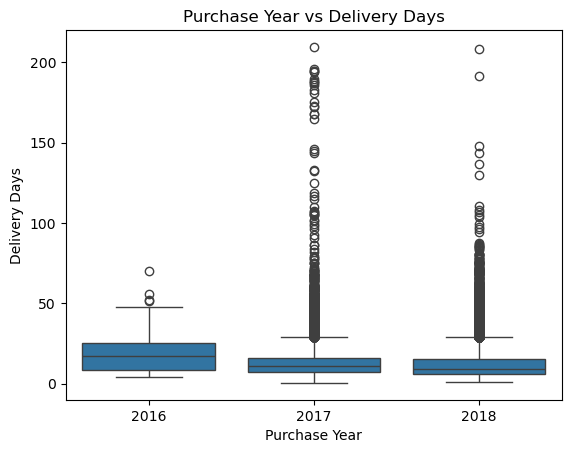

In [113]:
#purchase year vs delivery days :
sns.boxplot(
    x=X_train["purchase_year"],
    y=y_train
)

plt.xlabel("Purchase Year")
plt.ylabel("Delivery Days")
plt.title("Purchase Year vs Delivery Days")
plt.show()

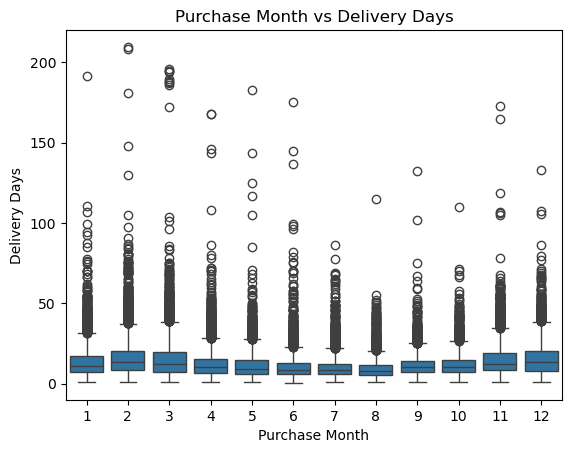

In [114]:
#purchase month vs delivery days :
sns.boxplot(
    x=X_train["purchase_month"],
    y=y_train
)

plt.xlabel("Purchase Month")
plt.ylabel("Delivery Days")
plt.title("Purchase Month vs Delivery Days")
plt.show()

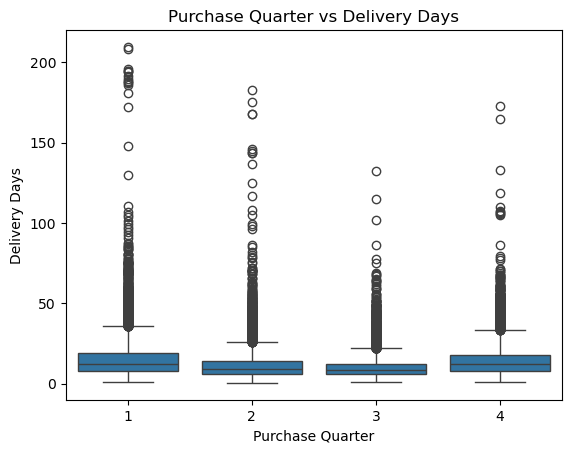

In [115]:
#purchase quarter vs delivery days :
sns.boxplot(
    x=X_train["purchase_quarter"],
    y=y_train
)

plt.xlabel("Purchase Quarter")
plt.ylabel("Delivery Days")
plt.title("Purchase Quarter vs Delivery Days")
plt.show()

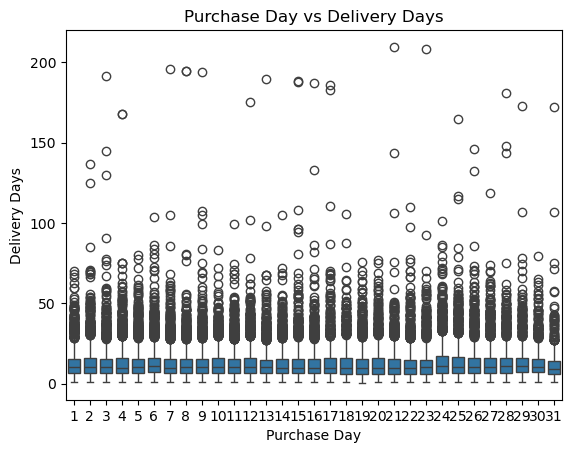

In [116]:
#purchase day vs delivery days :
sns.boxplot(
    x=X_train["purchase_day"],
    y=y_train
)

plt.xlabel("Purchase Day")
plt.ylabel("Delivery Days")
plt.title("Purchase Day vs Delivery Days")
plt.show()

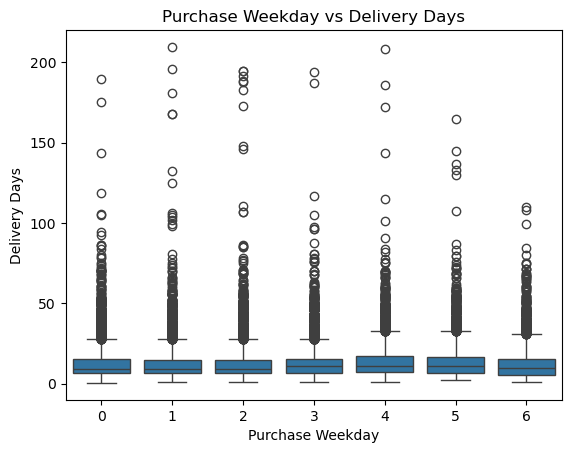

In [117]:
#purchase weekday vs delivery days :
sns.boxplot(
    x=X_train["purchase_weekday"],
    y=y_train
)

plt.xlabel("Purchase Weekday")
plt.ylabel("Delivery Days")
plt.title("Purchase Weekday vs Delivery Days")
plt.show()

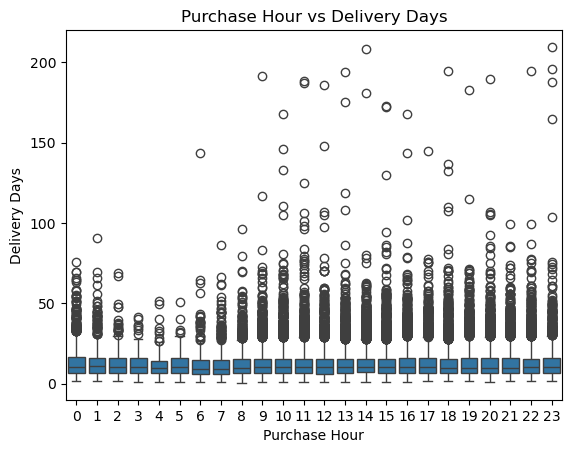

In [118]:
#purchase hour vs delivery days :
sns.boxplot(
    x=X_train["purchase_hour"],
    y=y_train
)

plt.xlabel("Purchase Hour")
plt.ylabel("Delivery Days")
plt.title("Purchase Hour vs Delivery Days")
plt.show()

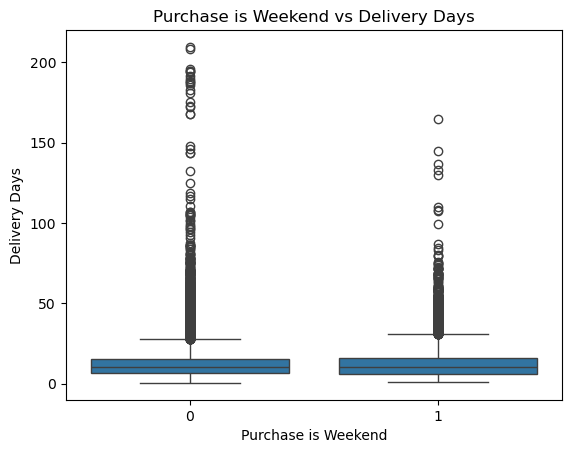

In [119]:
#purchase is weekend vs delivery days :
sns.boxplot(
    x=X_train["purchase_is_weekend"],
    y=y_train
)

plt.xlabel("Purchase is Weekend")
plt.ylabel("Delivery Days")
plt.title("Purchase is Weekend vs Delivery Days")
plt.show()

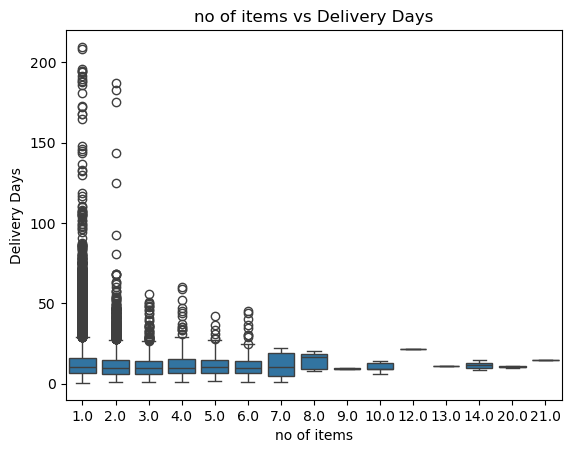

In [120]:
#no of items vs delivery days :
sns.boxplot(
    x=X_train["num_items"],
    y=y_train
)

plt.xlabel("no of items")
plt.ylabel("Delivery Days")
plt.title("no of items vs Delivery Days")
plt.show()

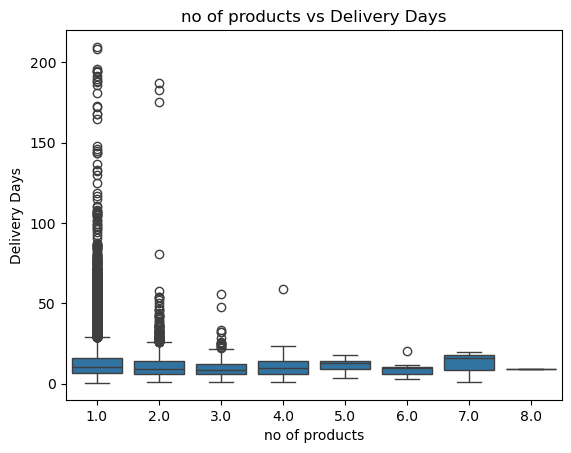

In [121]:
#no of products vs delivery days :
sns.boxplot(
    x=X_train["num_products"],
    y=y_train
)

plt.xlabel("no of products")
plt.ylabel("Delivery Days")
plt.title("no of products vs Delivery Days")
plt.show()

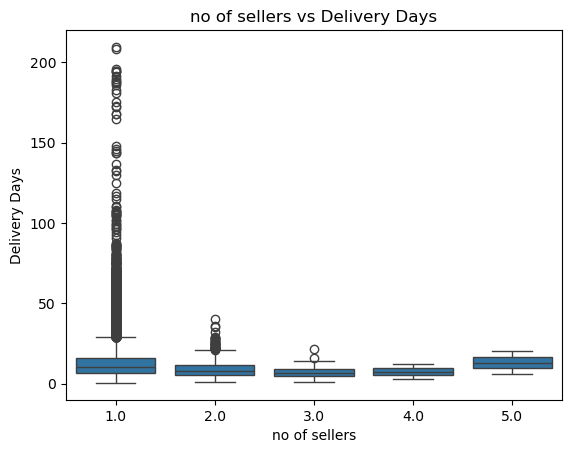

In [122]:
#no of sellers vs delivery days :
sns.boxplot(
    x=X_train["num_sellers"],
    y=y_train
)

plt.xlabel("no of sellers")
plt.ylabel("Delivery Days")
plt.title("no of sellers vs Delivery Days")
plt.show()

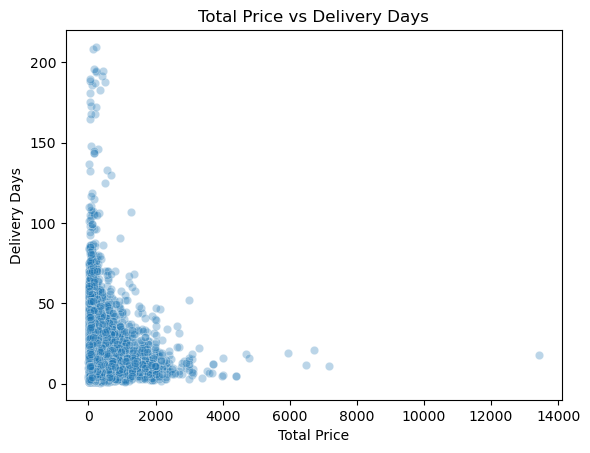

In [123]:
#total price vs delivery days :
sns.scatterplot(
    x=X_train["total_price"],
    y=y_train,
    alpha = 0.3
)
plt.xlabel("Total Price")
plt.ylabel("Delivery Days")
plt.title("Total Price vs Delivery Days")
plt.show()

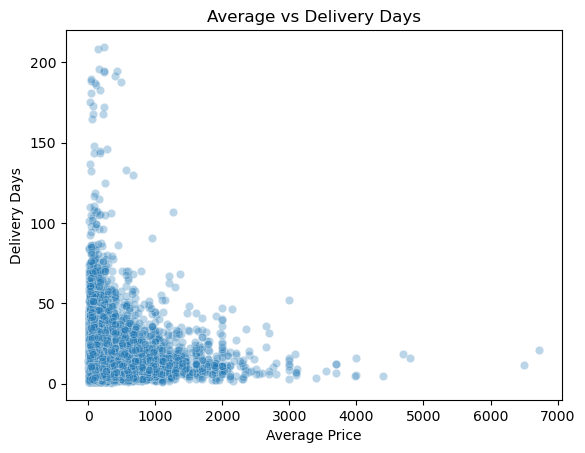

In [124]:
#average price vs delivery days :
sns.scatterplot(
    x=X_train["avg_price"],
    y=y_train,
    alpha = 0.3
)
plt.xlabel("Average Price")
plt.ylabel("Delivery Days")
plt.title("Average vs Delivery Days")
plt.show()

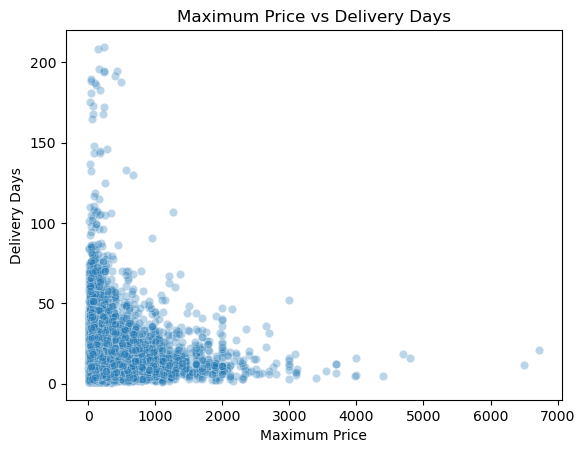

In [125]:
#maximum price vs delivery days :
sns.scatterplot(
    x=X_train["max_price"],
    y=y_train,
    alpha = 0.3
)
plt.xlabel("Maximum Price")
plt.ylabel("Delivery Days")
plt.title("Maximum Price vs Delivery Days")
plt.show()

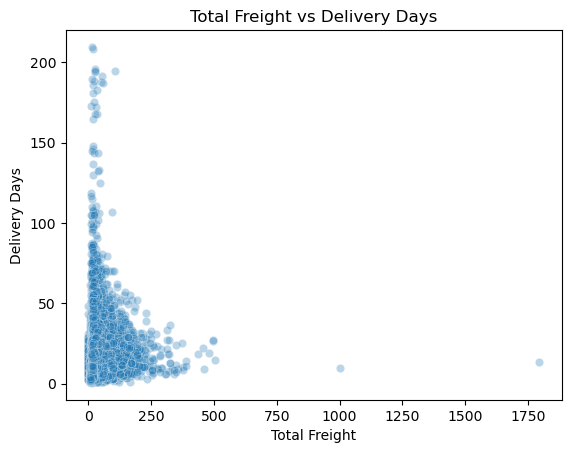

In [126]:
#total freight vs delivery days :
sns.scatterplot(
    x=X_train["total_freight"],
    y=y_train,
    alpha = 0.3
)
plt.xlabel("Total Freight")
plt.ylabel("Delivery Days")
plt.title("Total Freight vs Delivery Days")
plt.show()

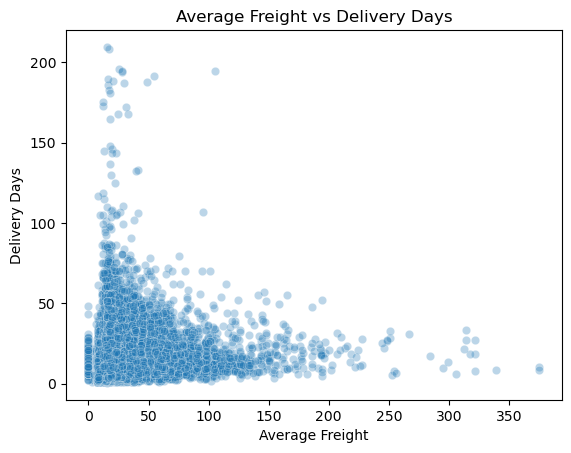

In [127]:
#average freight vs delivery days :
sns.scatterplot(
    x=X_train["avg_freight"],
    y=y_train,
    alpha = 0.3
)
plt.xlabel("Average Freight")
plt.ylabel("Delivery Days")
plt.title("Average Freight vs Delivery Days")
plt.show()

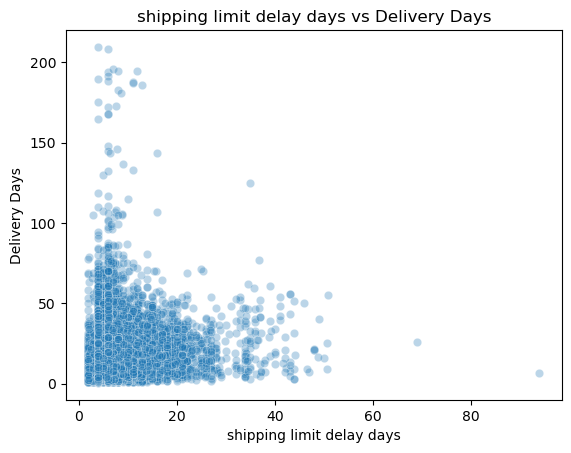

In [128]:
#shipping limit delay days vs delivery days :
sns.scatterplot(
    x=X_train["shipping_limit_delay_days"],
    y=y_train,
    alpha = 0.3
)
plt.xlabel("shipping limit delay days")
plt.ylabel("Delivery Days")
plt.title("shipping limit delay days vs Delivery Days")
plt.show()

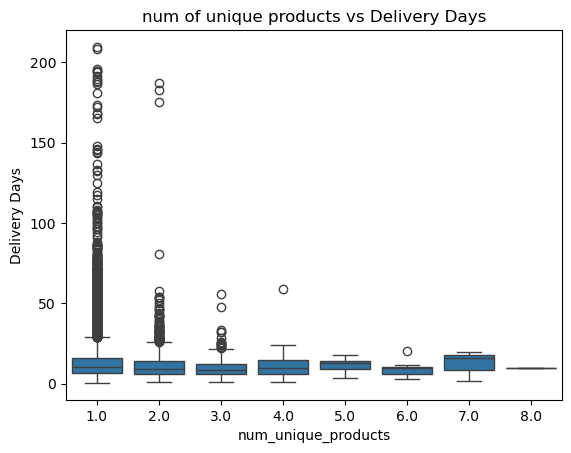

In [129]:
#num of unique products vs delivery days :
sns.boxplot(
    x=X_train["num_unique_products"],
    y=y_train
)
plt.xlabel("num_unique_products")
plt.ylabel("Delivery Days")
plt.title("num of unique products vs Delivery Days")
plt.show()

## Avoiding Data Leakage
The following columns are excluded from the feature set because they are only
known *after* delivery has already happened, and including them would let the
model "cheat" by seeing outcome information:

- `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`
- `order_estimated_delivery_date`
- `order_status` (constant here, since the target is only defined for delivered orders)

`shipping_limit_date` (and features derived from it, e.g. `shipping_limit_delay_days`)
is kept, since it's a seller commitment date set at order time, not a
post-delivery outcome.

Note: since the target requires a known delivery date, this model is trained only
on delivered orders. It would not directly generalize to predicting whether an
order gets cancelled or lost in transit.

In [131]:
features_to_remove = [
    'order_id',
    'customer_id',
    'customer_unique_id',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

X_train = X_train.drop(columns=features_to_remove)
X_cv = X_cv.drop(columns=features_to_remove)
X_test = X_test.drop(columns=features_to_remove)

In [132]:
print("Train:", X_train.shape)
print("CV:", X_cv.shape)
print("Test:", X_test.shape)

Train: (67199, 48)
CV: (14400, 48)
Test: (14400, 48)


In [133]:
features_to_remove = [
    'order_status',
    'seller_city',
    'customer_city',
    'customer_zip_code_prefix',
    'seller_zip_code_prefix'
]

X_train = X_train.drop(columns=features_to_remove)
X_cv = X_cv.drop(columns=features_to_remove)
X_test = X_test.drop(columns=features_to_remove)

print("Train:", X_train.shape)
print("CV:", X_cv.shape)
print("Test:", X_test.shape)

Train: (67199, 43)
CV: (14400, 43)
Test: (14400, 43)


In [134]:
categorical_features = [
    'seller_state',
    'customer_state'
]

numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nCategorical:")
print(categorical_features)

print("\nNumerical:")
print(numerical_features)

Number of numerical features: 41
Number of categorical features: 2

Categorical:
['seller_state', 'customer_state']

Numerical:
['purchase_year', 'purchase_month', 'purchase_quarter', 'purchase_day', 'purchase_weekday', 'purchase_hour', 'purchase_is_weekend', 'num_items', 'num_products', 'num_sellers', 'total_price', 'avg_price', 'max_price', 'total_freight', 'avg_freight', 'shipping_limit_delay_days', 'num_unique_products', 'avg_product_weight_g', 'max_product_weight_g', 'total_product_weight_g', 'avg_product_length_cm', 'avg_product_height_cm', 'avg_product_width_cm', 'avg_product_volume_cm3', 'max_product_volume_cm3', 'avg_product_photos_qty', 'avg_product_description_length', 'num_unique_seller_states', 'num_unique_seller_cities', 'total_payment_value', 'num_payment_records', 'max_payment_sequential', 'max_payment_installments', 'payment_type_count', 'has_credit_card', 'has_boleto', 'has_voucher', 'has_debit_card', 'has_not_defined', 'seller_customer_distance_km', 'seller_customer_

In [135]:

corr_matrix = X_train[numerical_features].corr()

# Show only pairs with |correlation| >= 0.7
strong_corr = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

strong_corr.columns = ["Feature_1", "Feature_2", "Correlation"]

strong_corr = (
    strong_corr[
        strong_corr["Correlation"].abs() >= 0.7
    ]
    .sort_values(
        "Correlation",
        key=lambda x: x.abs(),
        ascending=False
    )
)

strong_corr

,Feature_1,Feature_2,Correlation
291,num_products,num_unique_products,1.000000
374,avg_price,max_price,0.997947
735,num_payment_records,max_payment_sequential,0.997003
527,avg_product_weight_g,max_product_weight_g,0.996304
644,avg_product_volume_cm3,max_product_volume_cm3,0.996186
363,total_price,total_payment_value,0.995906
39,purchase_month,purchase_quarter,0.969747
346,total_price,max_price,0.926757
345,total_price,avg_price,0.922319
418,max_price,total_payment_value,0.915606


In [136]:
features_to_remove = [
    "num_unique_products",
    "max_price",
    "avg_price",
    "total_payment_value",
    "max_payment_sequential",
    "purchase_quarter",
    "max_product_weight_g",
    "max_product_volume_cm3",
    "num_unique_seller_cities",
    "purchase_is_weekend"
]

In [137]:
selected_features = [
    f for f in numerical_features
    if f not in features_to_remove
]

print("Features before:", len(numerical_features))
print("Features after:", len(selected_features))

Features before: 41
Features after: 31


In [138]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), selected_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            drop='first',
            sparse_output=False
        ), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_cv_processed = preprocessor.transform(X_cv)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed CV shape:", X_cv_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (67199, 78)
Processed CV shape: (14400, 78)
Processed test shape: (14400, 78)


In [139]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return mae, rmse, r2

In [140]:
mlr = LinearRegression()

mlr.fit(X_train_processed, y_train)

mlr_train_pred = mlr.predict(X_train_processed)
mlr_cv_pred = mlr.predict(X_cv_processed)

evaluate_model(
    "Multiple Linear Regression - Train",
    y_train,
    mlr_train_pred
)

evaluate_model(
    "Multiple Linear Regression - CV",
    y_cv,
    mlr_cv_pred
)


Multiple Linear Regression - Train
----------------------------------------
MAE  : 5.1662
RMSE : 8.3618
R²   : 0.2485

Multiple Linear Regression - CV
----------------------------------------
MAE  : 899982520.9519
RMSE : 107997901904.5076
R²   : -140489990073875267584.0000


(899982520.9519329, 107997901904.50764, -1.4048999007387527e+20)

In [141]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_processed, y_train)

ridge_train_pred = ridge.predict(X_train_processed)
ridge_cv_pred = ridge.predict(X_cv_processed)

evaluate_model(
    "Ridge - Train",
    y_train,
    ridge_train_pred
)

evaluate_model(
    "Ridge - CV",
    y_cv,
    ridge_cv_pred
)


Ridge - Train
----------------------------------------
MAE  : 5.1689
RMSE : 8.3625
R²   : 0.2484

Ridge - CV
----------------------------------------
MAE  : 5.0872
RMSE : 7.7963
R²   : 0.2679


(5.087246858479648, 7.796252464011593, 0.2678728143478297)

In [142]:
ridge_alphas = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

ridge_results = []

for alpha in ridge_alphas:

    model = Ridge(alpha=alpha)

    model.fit(X_train_processed, y_train)

    pred = model.predict(X_cv_processed)

    mae = mean_absolute_error(y_cv, pred)
    rmse = np.sqrt(mean_squared_error(y_cv, pred))
    r2 = r2_score(y_cv, pred)

    ridge_results.append({
        "alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

ridge_results = pd.DataFrame(ridge_results)

print(ridge_results)

      alpha       MAE      RMSE        R2
0     0.001  5.087699  7.796765  0.267777
1     0.010  5.087683  7.796750  0.267779
2     0.100  5.087577  7.796647  0.267799
3     1.000  5.087247  7.796252  0.267873
4    10.000  5.086373  7.794508  0.268200
5   100.000  5.086665  7.792525  0.268573
6  1000.000  5.096996  7.801951  0.266802


In [143]:
best_ridge_alpha = ridge_results.loc[
    ridge_results["RMSE"].idxmin(),
    "alpha"
]

print("Best Ridge alpha:", best_ridge_alpha)

Best Ridge alpha: 100.0


In [144]:
lasso_alphas = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]

lasso_results = []

for alpha in lasso_alphas:

    model = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    model.fit(X_train_processed, y_train)

    pred = model.predict(X_cv_processed)

    mae = mean_absolute_error(y_cv, pred)
    rmse = np.sqrt(mean_squared_error(y_cv, pred))
    r2 = r2_score(y_cv, pred)

    lasso_results.append({
        "alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

lasso_results = pd.DataFrame(lasso_results)

print(lasso_results)

     alpha       MAE      RMSE        R2
0    0.001  5.086770  7.794706  0.268163
1    0.010  5.093399  7.797737  0.267594
2    0.100  5.143406  7.858682  0.256101
3    1.000  5.426100  8.133465  0.203170
4   10.000  6.378016  9.111760 -0.000045
5  100.000  6.378016  9.111760 -0.000045


In [145]:
best_lasso_alpha = lasso_results.loc[
    lasso_results["RMSE"].idxmin(),
    "alpha"
]

print("Best Lasso alpha:", best_lasso_alpha)

Best Lasso alpha: 0.001


In [146]:
elastic_results = []

alphas = [0.001, 0.01, 0.1, 1, 10]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

for alpha in alphas:

    for l1_ratio in l1_ratios:

        model = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=10000
        )

        model.fit(X_train_processed, y_train)

        pred = model.predict(X_cv_processed)

        mae = mean_absolute_error(y_cv, pred)
        rmse = np.sqrt(mean_squared_error(y_cv, pred))
        r2 = r2_score(y_cv, pred)

        elastic_results.append({
            "alpha": alpha,
            "l1_ratio": l1_ratio,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

elastic_results = pd.DataFrame(elastic_results)

print(elastic_results)

     alpha  l1_ratio       MAE      RMSE        R2
0    0.001       0.1  5.086193  7.792504  0.268577
1    0.001       0.3  5.086194  7.792603  0.268558
2    0.001       0.5  5.086184  7.792794  0.268522
3    0.001       0.7  5.086256  7.793192  0.268447
4    0.001       0.9  5.086498  7.793976  0.268300
5    0.010       0.1  5.094058  7.798967  0.267363
6    0.010       0.3  5.094230  7.799185  0.267322
7    0.010       0.5  5.094512  7.799381  0.267285
8    0.010       0.7  5.094235  7.799021  0.267353
9    0.010       0.9  5.093763  7.798305  0.267487
10   0.100       0.1  5.130286  7.837769  0.260055
11   0.100       0.3  5.133530  7.842631  0.259136
12   0.100       0.5  5.137046  7.847772  0.258165
13   0.100       0.7  5.140098  7.852792  0.257215
14   0.100       0.9  5.141800  7.856185  0.256573
15   1.000       0.1  5.387757  8.087310  0.212187
16   1.000       0.3  5.421515  8.123192  0.205181
17   1.000       0.5  5.437664  8.140672  0.201757
18   1.000       0.7  5.443005 

In [147]:
best_elastic = elastic_results.loc[
    elastic_results["RMSE"].idxmin()
]

print(best_elastic)

alpha       0.001000
l1_ratio    0.100000
MAE         5.086193
RMSE        7.792504
R2          0.268577
Name: 0, dtype: float64


In [148]:
best_ridge = Ridge(
    alpha=best_ridge_alpha
)

best_lasso = Lasso(
    alpha=best_lasso_alpha,
    max_iter=10000
)

best_elastic = ElasticNet(
    alpha=best_elastic["alpha"],
    l1_ratio=best_elastic["l1_ratio"],
    max_iter=10000
)

models = {
    "OLS": mlr,
    "Ridge": best_ridge,
    "Lasso": best_lasso,
    "Elastic Net": best_elastic
}

comparison = []

for name, model in models.items():

    model.fit(X_train_processed, y_train)

    pred = model.predict(X_cv_processed)

    comparison.append({
        "Model": name,
        "MAE": mean_absolute_error(y_cv, pred),
        "RMSE": np.sqrt(mean_squared_error(y_cv, pred)),
        "R2": r2_score(y_cv, pred)
    })

comparison = pd.DataFrame(comparison)

comparison = comparison.sort_values("RMSE")

print(comparison)

         Model           MAE          RMSE            R2
3  Elastic Net  5.086193e+00  7.792504e+00  2.685766e-01
1        Ridge  5.086665e+00  7.792525e+00  2.685728e-01
2        Lasso  5.086770e+00  7.794706e+00  2.681633e-01
0          OLS  8.999825e+08  1.079979e+11 -1.404900e+20


In [149]:
best_model_name = comparison.iloc[0]["Model"]

print("Best model:", best_model_name)

Best model: Elastic Net


In [150]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_processed, y_train)

rf_cv_pred = rf.predict(X_cv_processed)

evaluate_model(
    "Random Forest - CV",
    y_cv,
    rf_cv_pred
)


Random Forest - CV
----------------------------------------
MAE  : 4.5697
RMSE : 7.1638
R²   : 0.3818


(4.56973450236496, 7.163779928632909, 0.381842394967713)

In [151]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

xgb_cv_pred = xgb_model.predict(X_cv_processed)

evaluate_model(
    "XGBoost - CV",
    y_cv,
    xgb_cv_pred
)


XGBoost - CV
----------------------------------------
MAE  : 4.4850
RMSE : 7.1360
R²   : 0.3866


(4.484963080371738, 7.136000924534446, 0.3866271620173122)

In [152]:
models = {
    "OLS": mlr,
    "Ridge": best_ridge,
    "Lasso": best_lasso,
    "Elastic Net": best_elastic,
    "Random Forest": rf,
    "XGBoost": xgb_model
}

In [153]:
# Predict on the test set
xgb_test_pred = xgb_model.predict(X_test_processed)

# Evaluate
evaluate_model(
    "XGBoost - TEST",
    y_test,
    xgb_test_pred
)


XGBoost - TEST
----------------------------------------
MAE  : 4.5143
RMSE : 7.5428
R²   : 0.3685


(4.51433741760574, 7.542790135289784, 0.3684824597650431)

In [154]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Train predictions
xgb_train_pred = xgb_model.predict(X_train_processed)

# CV predictions
xgb_cv_pred = xgb_model.predict(X_cv_processed)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
cv_rmse = np.sqrt(mean_squared_error(y_cv, xgb_cv_pred))

print(f"XGBoost Train RMSE: {train_rmse:.4f}")
print(f"XGBoost CV RMSE:    {cv_rmse:.4f}")

XGBoost Train RMSE: 6.8190
XGBoost CV RMSE:    7.1360


In [155]:
comparison = []

for name, model in models.items():

    # Models are already fitted, but fitting again is harmless
    model.fit(X_train_processed, y_train)

    pred = model.predict(X_cv_processed)

    comparison.append({
        "Model": name,
        "MAE": mean_absolute_error(y_cv, pred),
        "RMSE": np.sqrt(mean_squared_error(y_cv, pred)),
        "R2": r2_score(y_cv, pred)
    })

comparison = pd.DataFrame(comparison)

comparison = comparison.sort_values("RMSE")

print(comparison)

           Model           MAE          RMSE            R2
5        XGBoost  4.484963e+00  7.136001e+00  3.866272e-01
4  Random Forest  4.569735e+00  7.163780e+00  3.818424e-01
3    Elastic Net  5.086193e+00  7.792504e+00  2.685766e-01
1          Ridge  5.086665e+00  7.792525e+00  2.685728e-01
2          Lasso  5.086770e+00  7.794706e+00  2.681633e-01
0            OLS  8.999825e+08  1.079979e+11 -1.404900e+20


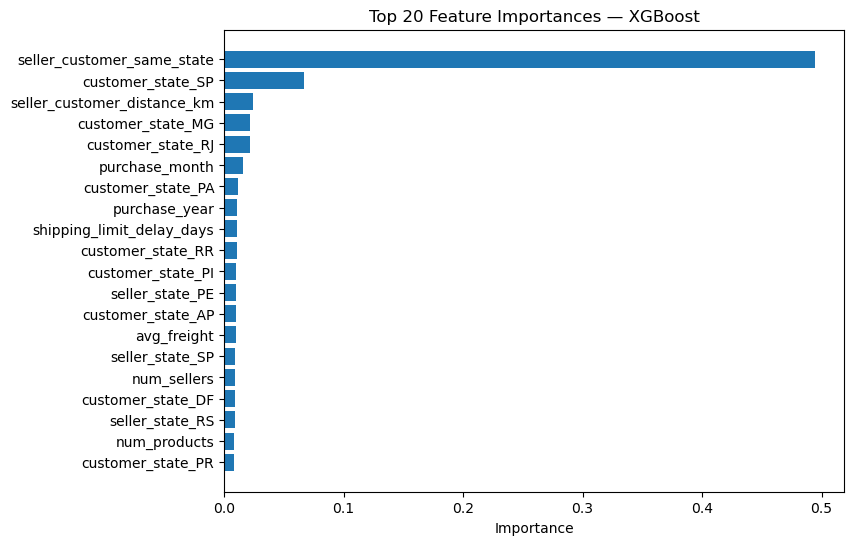

                        feature  importance
30   seller_customer_same_state    0.494063
76            customer_state_SP    0.066439
29  seller_customer_distance_km    0.024356
61            customer_state_MG    0.021505
69            customer_state_RJ    0.021444
1                purchase_month    0.016160
64            customer_state_PA    0.011423
0                 purchase_year    0.011129
11    shipping_limit_delay_days    0.010695
72            customer_state_RR    0.010433
67            customer_state_PI    0.010029
42              seller_state_PE    0.009965
54            customer_state_AP    0.009754
10                  avg_freight    0.009736
51              seller_state_SP    0.009537
7                   num_sellers    0.009490
57            customer_state_DF    0.009030
48              seller_state_RS    0.008866
6                  num_products    0.008561
68            customer_state_PR    0.008396


In [156]:

importances = xgb_model.feature_importances_
feature_names = selected_features + list(
    preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(8,6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances — XGBoost')
plt.show()

print(importance_df)

In [157]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Test predictions
xgb_test_pred = xgb_model.predict(X_test_processed)

# Test metrics
test_mae = mean_absolute_error(y_test, xgb_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
test_r2 = r2_score(y_test, xgb_test_pred)

print("XGBoost Test Performance")
print("------------------------")
print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

XGBoost Test Performance
------------------------
MAE  : 4.5143
RMSE : 7.5428
R²   : 0.3685


In [158]:
# Train predictions
xgb_train_pred = xgb_model.predict(X_train_processed)

train_mae = mean_absolute_error(y_train, xgb_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
train_r2 = r2_score(y_train, xgb_train_pred)

# CV metrics
cv_mae = mean_absolute_error(y_cv, xgb_cv_pred)
cv_rmse = np.sqrt(mean_squared_error(y_cv, xgb_cv_pred))
cv_r2 = r2_score(y_cv, xgb_cv_pred)

# Test metrics
test_mae = mean_absolute_error(y_test, xgb_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
test_r2 = r2_score(y_test, xgb_test_pred)

comparison = pd.DataFrame({
    "Dataset": ["Train", "Cross-Validation", "Test"],
    "MAE": [train_mae, cv_mae, test_mae],
    "RMSE": [train_rmse, cv_rmse, test_rmse],
    "R2": [train_r2, cv_r2, test_r2]
})

comparison

,Dataset,MAE,RMSE,R2
0,Train,4.244901,6.818969,0.500256
1,Cross-Validation,4.484963,7.136001,0.386627
2,Test,4.514337,7.542790,0.368482


In [319]:
# 1. Log-transform the target (log1p handles delivery_days=0 safely, if any exist)
y_train_log = np.log1p(y_train)
y_cv_log = np.log1p(y_cv)
y_test_log = np.log1p(y_test)

# 2. Refit the same pipeline on the log-transformed target
grid.fit(X_train_top20, y_train_log)

print("Best alpha:", grid.best_params_['ridge__alpha'])
print("Best CV RMSE (log scale):", -grid.best_score_)

best_model_log = grid.best_estimator_

# 3. Evaluate — predict in log scale, then invert back with expm1 for real-world metrics
def evaluate_log(model, X, y_true_original, label):
    preds_log = model.predict(X)
    preds_original = np.expm1(preds_log)          # invert log1p
    preds_original = np.clip(preds_original, 0, None)  # delivery days can't be negative

    mae = mean_absolute_error(y_true_original, preds_original)
    rmse = np.sqrt(mean_squared_error(y_true_original, preds_original))
    r2 = r2_score(y_true_original, preds_original)
    print(f"{label:15s}  MAE: {mae:.4f}   RMSE: {rmse:.4f}   R2: {r2:.4f}")
    return {'Dataset': label, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results_log = []
results_log.append(evaluate_log(best_model_log, X_train_top20, y_train, "Train"))
results_log.append(evaluate_log(best_model_log, X_cv_top20, y_cv, "Cross-Validation"))
results_log.append(evaluate_log(best_model_log, X_test_top20, y_test, "Test"))

results_log_df = pd.DataFrame(results_log)
print(results_log_df)

Best alpha: 0.1
Best CV RMSE (log scale): 0.45996306581844093
Train            MAE: 4.8100   RMSE: 8.3779   R2: 0.2456
Cross-Validation  MAE: 4.7289   RMSE: 7.7794   R2: 0.2710
Test             MAE: 4.7358   RMSE: 8.1412   R2: 0.2643
            Dataset       MAE      RMSE        R2
0             Train  4.809954  8.377937  0.245631
1  Cross-Validation  4.728933  7.779368  0.271041
2              Test  4.735756  8.141179  0.264308
